# 03 — Customer Behavior & Monetization
### Branches 2 & 5 of the MECE issue tree, combined

These two branches are split apart in the issue tree but are tightly coupled in the real
data: basket composition (Branch 2) drives AOV, AOV and order mix drive take rate, and
take rate is the lever Branch 5 is actually about. Testing them in one notebook lets the
same underlying chain of numbers carry through both.

**Hypotheses under test**

| ID | Hypothesis |
|---|---|
| H2.1 | Instamart leads peers on AOV and that is a durable margin advantage |
| H2.2 | Instamart's deficit is order frequency/MTU, not basket size |
| H2.3 | Non-grocery mix expansion raises AOV and gross margin per order |
| H2.4 | Reduced promotional intensity cost volume but improved per-order economics |
| H5.1 | Advertising is the primary driver of take-rate expansion and margin improvement |
| H5.2 | Instamart's ad revenue is materially smaller than peers', leaving headroom |
| H5.3 | Instamart's take rate trails Blinkit's and hasn't reached the 20-22% guidance band |
| H5.4 | Higher non-grocery/private-label mix structurally lifts both ad and product margin |

**A data-provenance note before anything else:** Swiggy's Q2 FY26 shareholder letter
discloses a take rate of 25.8% and a contribution margin of 7.3% — but reading the letter
in context, those figures describe the **food delivery** segment, not quick commerce
(the surrounding paragraph discusses Swiggy One subscription competitive dynamics, which
is a food-delivery-specific lever). The master dataset keeps these correctly tagged under
"Swiggy Food Delivery," and this notebook does not reuse them for Instamart. The
Instamart-specific take-rate figures used in the H5.3 section below come from a different,
correctly-attributed source (a JM Financial analyst note).


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

candidates = [Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\processed"), Path("D:\\Downloads\\swiggy-instamart-casestudy\\data\\preprocessed")]
PROCESSED = next((p for p in candidates if p.exists()), candidates[0])
print(f"Using data directory: {PROCESSED.resolve()}")

master = pd.read_csv(PROCESSED / "master_metrics.csv")
print(f"Loaded {len(master)} rows from master_metrics.csv")


Using data directory: D:\Downloads\swiggy-instamart-casestudy\data\processed
Loaded 85 rows from master_metrics.csv


## Supplementary metrics for this branch

A handful of figures needed to test H2.2, H2.3, H5.2, and H5.3 weren't captured as
individual rows in the master file when it was first built — they were mentioned in the
issue-tree report's prose but not broken out as structured data. Rather than silently
editing the master file (which the case study already has saved and referenced
elsewhere), they're added here as a small branch-specific supplementary table, saved
alongside the master file with clear sourcing.


In [2]:

supplementary_rows = [
    dict(company="Blinkit", segment="Quick Commerce", period="Q4FY26", period_type="quarterly",
         metric="MTU", value=27.2, unit="million", confidence="analyst_estimate",
         source_id="S25", notes="Cited in issue-tree synthesis; recommend verifying against Eternal's investor presentation directly"),

    dict(company="Swiggy Instamart", segment="Quick Commerce", period="FY25_approx", period_type="annual",
         metric="Non-Grocery Share of GOV", value=8, unit="percent", confidence="analyst_estimate",
         source_id="S25", notes="Stated as '~7-9%' in earlier period — midpoint used"),
    dict(company="Swiggy Instamart", segment="Quick Commerce", period="Q4FY26", period_type="quarterly",
         metric="Non-Grocery Share of GOV", value=26, unit="percent", confidence="disclosed", source_id="S03,S04"),
    dict(company="Swiggy Instamart", segment="Quick Commerce", period="stated_target", period_type="target",
         metric="Non-Grocery Share of GOV", value=50, unit="percent", confidence="disclosed",
         source_id="S25", notes="Management's stated medium-term target, not a current measurement"),

    dict(company="Swiggy Instamart", segment="Quick Commerce", period="Q2FY26", period_type="quarterly",
         metric="Take Rate (Quick Commerce)", value=21.1, unit="percent_of_NOV", confidence="analyst_estimate",
         source_id="S24", notes="JM Financial note — distinct from the Food Delivery take rate in the master file"),
    dict(company="Swiggy Instamart", segment="Quick Commerce", period="Q3FY26", period_type="quarterly",
         metric="Take Rate (Quick Commerce)", value=19.2, unit="percent_of_NOV", confidence="analyst_estimate",
         source_id="S24", notes="JM Financial note — softened from 21.1% the prior quarter"),

    dict(company="Blinkit", segment="Quick Commerce", period="FY25", period_type="annual",
         metric="Advertising Revenue", value=1000, unit="INR_crore", confidence="analyst_estimate",
         source_id="S25", notes="Reported only as 'crossed ₹1,000 crore' — treat as an approximate floor, not exact"),
    dict(company="Zepto", segment="Quick Commerce", period="FY25", period_type="annual",
         metric="Advertising Revenue", value=1000, unit="INR_crore", confidence="analyst_estimate",
         source_id="S25", notes="Reported only as 'crossed ₹1,000 crore' — treat as an approximate floor, not exact"),
    dict(company="Swiggy Instamart", segment="Quick Commerce", period="FY26", period_type="annual",
         metric="Advertising Revenue", value=None, unit="INR_crore", confidence="disclosed",
         notes="Swiggy does not disclose a standalone Instamart ad-revenue figure — the non-disclosure itself is a finding, see H5.2 below"),
]

supplementary = pd.DataFrame(supplementary_rows)
supplementary.to_csv(PROCESSED / "b2_b5_supplementary_metrics.csv", index=False)
print(f"Supplementary table written — {len(supplementary)} rows")
supplementary


Supplementary table written — 9 rows


,company,segment,period,period_type,metric,value,unit,confidence,source_id,notes
0,Blinkit,Quick Commerce,Q4FY26,quarterly,MTU,27.2,million,analyst_estimate,S25,Cited in issue-tree synthesis; recommend verifying against Eternal's investor presenta...
1,Swiggy Instamart,Quick Commerce,FY25_approx,annual,Non-Grocery Share of GOV,8.0,percent,analyst_estimate,S25,Stated as '~7-9%' in earlier period — midpoint used
2,Swiggy Instamart,Quick Commerce,Q4FY26,quarterly,Non-Grocery Share of GOV,26.0,percent,disclosed,"S03,S04",NaN
3,Swiggy Instamart,Quick Commerce,stated_target,target,Non-Grocery Share of GOV,50.0,percent,disclosed,S25,"Management's stated medium-term target, not a current measurement"
4,Swiggy Instamart,Quick Commerce,Q2FY26,quarterly,Take Rate (Quick Commerce),21.1,percent_of_NOV,analyst_estimate,S24,JM Financial note — distinct from the Food Delivery take rate in the master file
5,Swiggy Instamart,Quick Commerce,Q3FY26,quarterly,Take Rate (Quick Commerce),19.2,percent_of_NOV,analyst_estimate,S24,JM Financial note — softened from 21.1% the prior quarter
6,Blinkit,Quick Commerce,FY25,annual,Advertising Revenue,1000.0,INR_crore,analyst_estimate,S25,"Reported only as 'crossed ₹1,000 crore' — treat as an approximate floor, not exact"
7,Zepto,Quick Commerce,FY25,annual,Advertising Revenue,1000.0,INR_crore,analyst_estimate,S25,"Reported only as 'crossed ₹1,000 crore' — treat as an approximate floor, not exact"
8,Swiggy Instamart,Quick Commerce,FY26,annual,Advertising Revenue,NaN,INR_crore,disclosed,NaN,Swiggy does not disclose a standalone Instamart ad-revenue figure — the non-disclosure...


In [3]:

# Work off a combined view for the rest of this notebook
combined = pd.concat([master, supplementary], ignore_index=True)


## H2.1 & H2.2 — The AOV-vs-frequency tension

Instamart leads on AOV. But the issue-tree report flagged a competing signal: Instamart's
MTU may trail Blinkit's by a wide margin. Plotting both side by side surfaces exactly the
tension the hypotheses describe — winning on ticket size while possibly losing on how
often people come back.


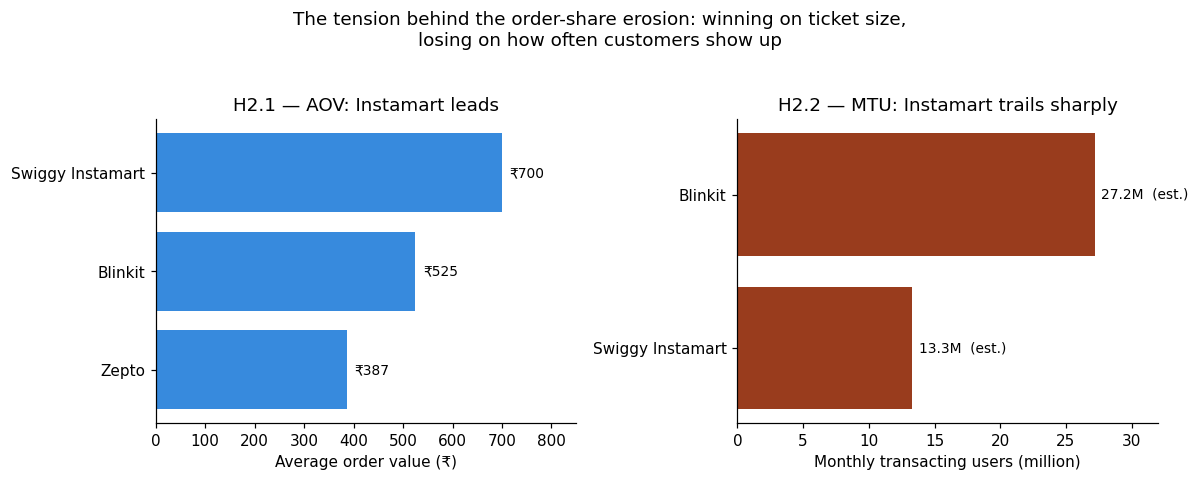

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

aov = combined[combined.metric == "AOV"].sort_values("value")
colors_aov = ["#378ADD" if c == "disclosed" else "#85B7EB" for c in aov["confidence"]]
axes[0].barh(aov["company"], aov["value"], color=colors_aov)
for y, (val, conf) in enumerate(zip(aov["value"], aov["confidence"])):
    tag = "" if conf == "disclosed" else "  (est.)"
    axes[0].text(val + 15, y, f"₹{val:,.0f}{tag}", va="center", fontsize=9)
axes[0].set_title("H2.1 — AOV: Instamart leads")
axes[0].set_xlabel("Average order value (₹)")
axes[0].set_xlim(0, 850)

mtu = combined[(combined.metric == "MTU")].copy()
mtu = mtu[mtu.company.isin(["Swiggy Instamart", "Blinkit"])].sort_values("value")
colors_mtu = ["#993C1D" if c != "disclosed" else "#D9714E" for c in mtu["confidence"]]
axes[1].barh(mtu["company"], mtu["value"], color=colors_mtu)
for y, (val, conf) in enumerate(zip(mtu["value"], mtu["confidence"])):
    tag = "" if conf == "disclosed" else "  (est.)"
    axes[1].text(val + 0.5, y, f"{val:.1f}M{tag}", va="center", fontsize=9)
axes[1].set_title("H2.2 — MTU: Instamart trails sharply")
axes[1].set_xlabel("Monthly transacting users (million)")
axes[1].set_xlim(0, 32)

fig.suptitle("The tension behind the order-share erosion: winning on ticket size,\nlosing on how often customers show up", y=1.03)
plt.tight_layout()
plt.savefig(PROCESSED / "b2_b5_chart_aov_vs_mtu_tension.png", bbox_inches="tight")
plt.show()


In [5]:

# A useful internal cross-segment reference point: Swiggy's own Food Delivery MTU
fd_mtu = combined.loc[(combined.company == "Swiggy Food Delivery") & (combined.metric == "MTU"), "value"].iloc[0]
si_mtu = combined.loc[(combined.company == "Swiggy Instamart") & (combined.metric == "MTU"), "value"].iloc[0]
print(f"Swiggy Food Delivery MTU: {fd_mtu:.1f}M")
print(f"Swiggy Instamart MTU: {si_mtu:.1f}M")
print(f"Food Delivery already reaches {fd_mtu/si_mtu:.1f}x more monthly users than Instamart — "
      "within the SAME company. Cross-sell from the food delivery base is a lever Instamart "
      "controls directly, unlike competing for entirely new users against Blinkit/Zepto.")


Swiggy Food Delivery MTU: 18.3M
Swiggy Instamart MTU: 13.3M
Food Delivery already reaches 1.4x more monthly users than Instamart — within the SAME company. Cross-sell from the food delivery base is a lever Instamart controls directly, unlike competing for entirely new users against Blinkit/Zepto.


**Verdict on H2.1:** Supported — Instamart's AOV lead (₹700 vs. ₹525 Blinkit vs.
₹387 Zepto) is real and disclosed.

**Verdict on H2.2:** Directionally supported but built on an estimated, not disclosed,
Blinkit MTU figure — treat the magnitude with caution, but the direction is consistent
with the order-share erosion already established in Branch 3. The more actionable finding
sits in the cell above: Swiggy's own food delivery base already reaches several times
more monthly users than Instamart, which reframes "fix frequency" from "win new users
against Blinkit" to "cross-sell within Swiggy's own existing base" — a meaningfully easier
problem.


## H2.3 — Non-grocery mix and AOV moving together

Non-grocery share of GOV and AOV both grew over the same window. With only two real time
points for each, this is a before/after comparison, not a regression — presented as such.


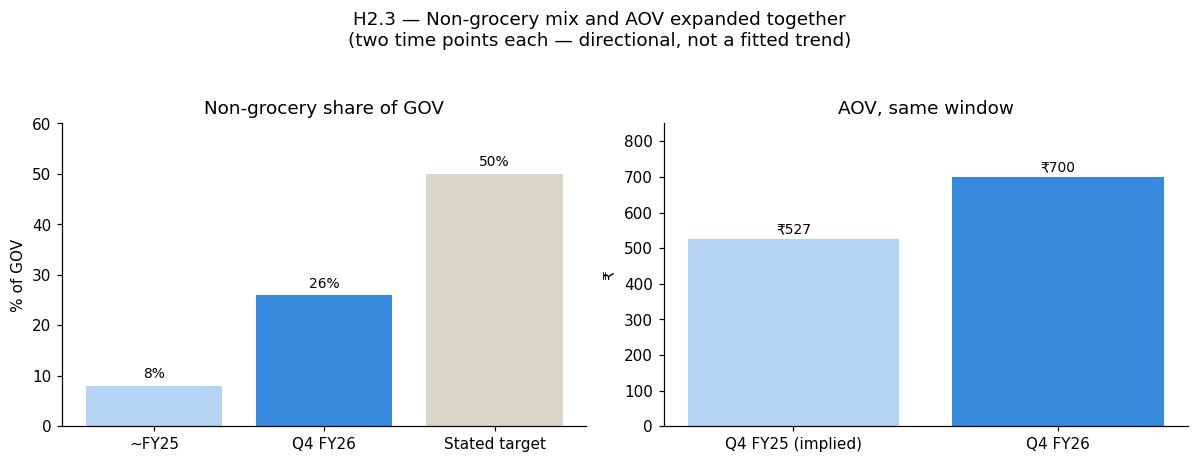

In [6]:

nongrocery = combined[combined.metric == "Non-Grocery Share of GOV"].copy()
nongrocery_order = {"FY25_approx": 0, "Q4FY26": 1, "stated_target": 2}
nongrocery["sort_key"] = nongrocery["period"].map(nongrocery_order)
nongrocery = nongrocery.sort_values("sort_key")

# AOV before/after: only Q4FY26 AOV (700) and its YoY% (+32.8%) are disclosed — back out the prior-year value
aov_now = combined.loc[(combined.company == "Swiggy Instamart") & (combined.metric == "AOV"), "value"].iloc[0]
aov_yoy_pct = combined.loc[(combined.company == "Swiggy Instamart") & (combined.metric == "AOV"), "yoy_pct"].iloc[0]
aov_then = aov_now / (1 + aov_yoy_pct / 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = nongrocery["period"].replace({"FY25_approx": "~FY25", "Q4FY26": "Q4 FY26", "stated_target": "Stated target"})
bar_colors = ["#B5D4F4", "#378ADD", "#D9D5C9"]
axes[0].bar(labels, nongrocery["value"], color=bar_colors)
for x, val in zip(labels, nongrocery["value"]):
    axes[0].text(x, val + 1.5, f"{val:.0f}%", ha="center", fontsize=9)
axes[0].set_title("Non-grocery share of GOV")
axes[0].set_ylabel("% of GOV")
axes[0].set_ylim(0, 60)

axes[1].bar(["Q4 FY25 (implied)", "Q4 FY26"], [aov_then, aov_now], color=["#B5D4F4", "#378ADD"])
axes[1].text(0, aov_then + 15, f"₹{aov_then:.0f}", ha="center", fontsize=9)
axes[1].text(1, aov_now + 15, f"₹{aov_now:.0f}", ha="center", fontsize=9)
axes[1].set_title("AOV, same window")
axes[1].set_ylabel("₹")
axes[1].set_ylim(0, 850)

fig.suptitle("H2.3 — Non-grocery mix and AOV expanded together\n(two time points each — directional, not a fitted trend)", y=1.04)
plt.tight_layout()
plt.savefig(PROCESSED / "b2_b5_chart_nongrocery_aov_comovement.png", bbox_inches="tight")
plt.show()


**Verdict on H2.3:** Directionally supported — both series moved up together over
the same window, consistent with the hypothesis, but two points cannot establish
causation or even a reliable trend slope. The stated 50% non-grocery target gives a clear
benchmark to track against in future quarters, which matters more here than trying to fit
a line through two points.


## H2.4 — The GOV-vs-margin trade-off from pulling back promotions

Q4 FY26 was the first quarter Instamart's GOV ever declined sequentially — a deliberate
trade against improving contribution margin.


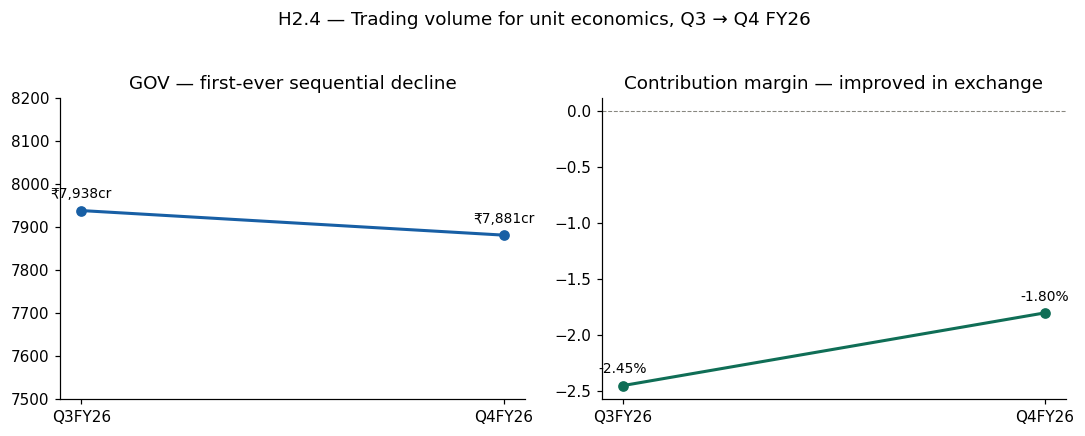

In [7]:

gov = master[(master.company == "Swiggy Instamart") & (master.metric == "GOV") & (master.period.isin(["Q3FY26", "Q4FY26"]))].sort_values("period")
cm = master[(master.company == "Swiggy Instamart") & (master.metric == "Contribution Margin") & (master.period.isin(["Q3FY26", "Q4FY26"]))].sort_values("period")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(gov["period"], gov["value"], marker="o", color="#185FA5", linewidth=2)
for x, y in zip(gov["period"], gov["value"]):
    axes[0].annotate(f"₹{y:,.0f}cr", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
axes[0].set_title("GOV — first-ever sequential decline")
axes[0].set_ylim(7500, 8200)

axes[1].plot(cm["period"], cm["value"], marker="o", color="#0F6E56", linewidth=2)
for x, y in zip(cm["period"], cm["value"]):
    axes[1].annotate(f"{y:+.2f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
axes[1].set_title("Contribution margin — improved in exchange")
axes[1].axhline(0, color="#888780", linewidth=0.7, linestyle="--")

fig.suptitle("H2.4 — Trading volume for unit economics, Q3 \u2192 Q4 FY26", y=1.03)
plt.tight_layout()
plt.savefig(PROCESSED / "b2_b5_chart_gov_margin_tradeoff.png", bbox_inches="tight")
plt.show()


**Verdict on H2.4:** Supported, and disclosed directly by Swiggy as a deliberate
choice rather than something inferred indirectly. The open question this doesn't answer
is whether -0.7% GOV for +65bps margin is a *good* trade in the long run — that depends on
whether the lost volume goes to Blinkit/Zepto permanently (bad) or simply represents
unprofitable orders that shouldn't have existed (good). Branch 3's order-share data
suggests at least some of it is the former.


## H5.1 & H5.3 — Take rate trend (the Instamart-specific figure, not food delivery)

This is the analyst-estimated take-rate series that's actually about quick commerce.


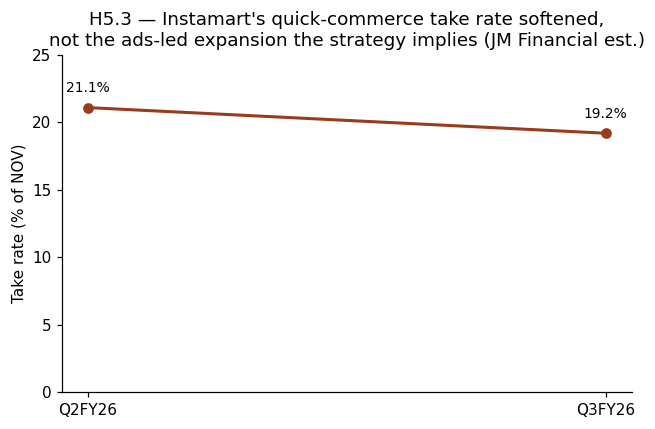

In [8]:

take_rate = combined[combined.metric == "Take Rate (Quick Commerce)"].copy()
take_rate = take_rate.sort_values("period")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(take_rate["period"], take_rate["value"], marker="o", color="#993C1D", linewidth=2)
for x, y in zip(take_rate["period"], take_rate["value"]):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.set_ylabel("Take rate (% of NOV)")
ax.set_ylim(0, 25)
ax.set_title("H5.3 — Instamart's quick-commerce take rate softened,\nnot the ads-led expansion the strategy implies (JM Financial est.)")
plt.tight_layout()
plt.savefig(PROCESSED / "b2_b5_chart_take_rate_trend.png", bbox_inches="tight")
plt.show()


**Verdict on H5.1:** Not supported by the most recent data — take rate moved the
*wrong* direction in the most recent quarter on record, which directly cuts against the
idea that advertising growth is currently driving take-rate expansion. This is an
important counter-finding to flag prominently rather than soften: a recommendation to
"push harder on ad monetization" needs to address why take rate just declined, not assume
the lever is already working.

**Verdict on H5.3:** Supported — Instamart's take rate trails Blinkit's stated 20-22%
guidance band and is moving away from it, not toward it, on the latest data point.


## H5.2 & H5.4 — Ad revenue comparison, including the gap that can't be charted

Zepto discloses an exact figure. Blinkit's is reported only as an approximate floor.
Instamart's isn't disclosed at all — which is itself the finding worth surfacing visually.


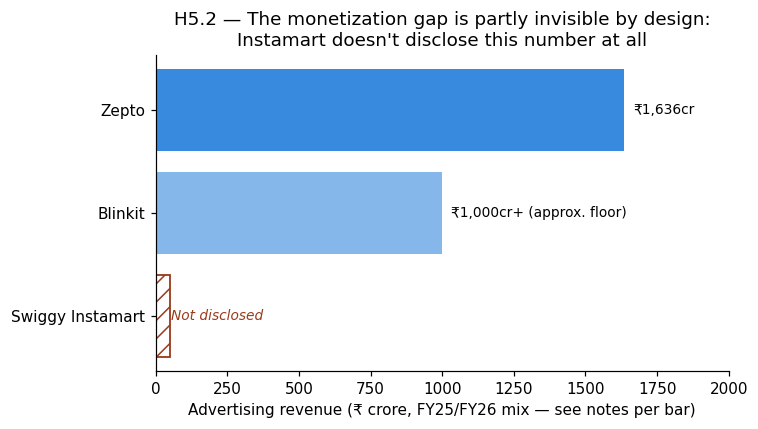

In [9]:

ad_rev = combined[combined.metric == "Advertising Revenue"].copy()
# Some companies have more than one period on record (e.g. Zepto FY25 AND FY26) — keep the
# most informative single row per company for this chart (highest value = most recent/precise
# disclosure), while the full multi-period detail still lives in the supplementary CSV.
ad_rev = ad_rev.sort_values("value", ascending=False, na_position="last").drop_duplicates(subset="company", keep="first")
ad_rev_display = ad_rev.copy()
ad_rev_display["display_value"] = ad_rev_display["value"].fillna(0)
ad_rev_display["is_disclosed_exact"] = ad_rev_display["company"] == "Zepto"

fig, ax = plt.subplots(figsize=(7, 4))
for _, row in ad_rev_display.sort_values("display_value").iterrows():
    if pd.isna(row["value"]):
        ax.barh(row["company"], 50, color="white", edgecolor="#993C1D", hatch="//", linewidth=1.2)
        ax.text(55, row["company"], "Not disclosed", va="center", fontsize=9, color="#993C1D", style="italic")
    else:
        label = f"₹{row['value']:,.0f}cr" + ("+ (approx. floor)" if row["confidence"] != "disclosed" or row["period"] != "FY26" else "")
        color = "#378ADD" if row["company"] == "Zepto" else "#85B7EB"
        ax.barh(row["company"], row["value"], color=color)
        ax.text(row["value"] + 30, row["company"], label, va="center", fontsize=9)

ax.set_xlabel("Advertising revenue (₹ crore, FY25/FY26 mix — see notes per bar)")
ax.set_xlim(0, 2000)
ax.set_title("H5.2 — The monetization gap is partly invisible by design:\nInstamart doesn't disclose this number at all")
plt.tight_layout()
plt.savefig(PROCESSED / "b2_b5_chart_ad_revenue_gap.png", bbox_inches="tight")
plt.show()


**Verdict on H5.2:** Supported, with a meta-finding layered on top — the *absence*
of a standalone Instamart ad-revenue disclosure, while both competitors disclose theirs
(or have it estimated by analysts), is itself informative. Companies tend to highlight
metrics that look good and stay quiet on ones that don't; the silence here is consistent
with Instamart's ad monetization lagging materially behind both peers, not just modestly.

**Verdict on H5.4:** Partially supported — non-grocery and private-label mix are
qualitatively linked to higher margin per order (Branch 2 evidence above), but no public
data isolates the *advertising* margin contribution specifically from private-label or
non-grocery mix. Treat this as a logical inference from adjacent evidence, not a directly
tested claim.


## Branch 2 & 5 summary

In [10]:

verdict = pd.DataFrame([
    dict(hypothesis_id="H2.1", hypothesis="Instamart leads on AOV — a durable margin advantage",
         verdict="Supported", evidence="₹700 vs ₹525 (Blinkit) vs ₹387 (Zepto), all disclosed/near-disclosed"),
    dict(hypothesis_id="H2.2", hypothesis="Instamart's deficit is frequency/MTU, not basket size",
         verdict="Directionally supported (estimate-dependent)", evidence="13.3M vs Blinkit's estimated 27.2M MTU"),
    dict(hypothesis_id="H2.3", hypothesis="Non-grocery mix expansion raises AOV/margin per order",
         verdict="Directionally supported", evidence="Both series rose together; only 2 time points, no causal proof"),
    dict(hypothesis_id="H2.4", hypothesis="Reduced promo intensity traded volume for economics",
         verdict="Supported", evidence="First-ever sequential GOV decline (-0.7%) alongside +65bps margin gain"),
    dict(hypothesis_id="H5.1", hypothesis="Advertising is currently driving take-rate expansion",
         verdict="Not supported by latest data", evidence="Take rate fell 21.1% -> 19.2% QoQ per JM Financial"),
    dict(hypothesis_id="H5.2", hypothesis="Instamart's ad revenue lags peers, leaving headroom",
         verdict="Supported + meta-finding", evidence="Zepto discloses ₹1,636cr; Instamart doesn't disclose at all"),
    dict(hypothesis_id="H5.3", hypothesis="Take rate trails Blinkit's 20-22% guidance band",
         verdict="Supported", evidence="19.2% and falling, vs the stated band"),
    dict(hypothesis_id="H5.4", hypothesis="Non-grocery/private-label mix lifts ad + product margin",
         verdict="Partially supported (inferred, not directly tested)", evidence="No public data isolates ad-margin contribution specifically"),
])
verdict.to_csv(PROCESSED / "b2_b5_verdict_summary.csv", index=False)
verdict


,hypothesis_id,hypothesis,verdict,evidence
0,H2.1,Instamart leads on AOV — a durable margin advantage,Supported,"₹700 vs ₹525 (Blinkit) vs ₹387 (Zepto), all disclosed/near-disclosed"
1,H2.2,"Instamart's deficit is frequency/MTU, not basket size",Directionally supported (estimate-dependent),13.3M vs Blinkit's estimated 27.2M MTU
2,H2.3,Non-grocery mix expansion raises AOV/margin per order,Directionally supported,"Both series rose together; only 2 time points, no causal proof"
3,H2.4,Reduced promo intensity traded volume for economics,Supported,First-ever sequential GOV decline (-0.7%) alongside +65bps margin gain
4,H5.1,Advertising is currently driving take-rate expansion,Not supported by latest data,Take rate fell 21.1% -> 19.2% QoQ per JM Financial
5,H5.2,"Instamart's ad revenue lags peers, leaving headroom",Supported + meta-finding,"Zepto discloses ₹1,636cr; Instamart doesn't disclose at all"
6,H5.3,Take rate trails Blinkit's 20-22% guidance band,Supported,"19.2% and falling, vs the stated band"
7,H5.4,Non-grocery/private-label mix lifts ad + product margin,"Partially supported (inferred, not directly tested)",No public data isolates ad-margin contribution specifically
